## Análisis de datos - Clase 2

## Introducción al EDA: medidas estadísticas descriptivas 
<hr style="border:1px solid gray">

In [1087]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe

#### Funciones auxiliares (helper functions)



In [1088]:
# Función para graficar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')
 

    # Sombreado
    if mvd and shade:
        plt.axvspan(media - std, media + std, alpha=0.1, color='orange', label='±1 Std')
        plt.axvline(media + std, color='orange', linestyle=':', label='+1 Std')
        plt.axvline(media - std, color='orange', linestyle=':', label='-1 Std')
        plt.figtext(0.15, 0.80, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var:   {var:.2f}',   fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std:   {std:.2f}',   fontsize=10, color='orange')

    

    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()
    
    return

In [1089]:
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

In [1090]:
def print_categorias(dataframe, columna):
    print(f"Cantidad de categorías que tiene la variable '{columna}': {dataframe[columna].nunique()}\n")
    print(f"Nombres de categorías presentes en la variable '{columna}': {dataframe[columna].unique()}\n")
    print(f"Frecuencia de cada categoría en la variable '{columna}':\n{dataframe[columna].value_counts()}\n")

In [1091]:
def plot_pie(data, column, ax=None, startangle=90, palette='pastel', title=None):
    counts = data[column].value_counts()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    
    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=startangle,
        colors=sns.color_palette(palette)
    )
    ax.set_title(title if title else f'Distribución de "{column}"')
    ax.axis('equal') # Asegura que el gráfico sea circular

In [1092]:
def plot_frecuencias_relativas(data, column, ax=None, palette='viridis', figsize=(9, 4), title=None):
    total = len(data)
    relative_freq = data[column].value_counts() / total

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(x=relative_freq.values, y=relative_freq.index, hue=relative_freq.index, 
                palette=palette, ax=ax, legend=False)
    
    ax.set_title(title if title else f'Frecuencias relativas de {column}')
    ax.set_xlabel('Frecuencia relativa')
    ax.set_ylabel(column)

plt.show()

In [1093]:
def plot_violin_box(data, num_col, cat_col, figsize=(12, 4), palette='pastel', title=None):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    # Violin plot
    sns.violinplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                   palette=palette, ax=axes[0], legend=False)
    axes[0].set_title(f'Violin: {num_col} vs. {cat_col}')
    axes[0].grid(axis='y', ls='--')

    # Box plot
    sns.boxplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                palette=palette, ax=axes[1], legend=False)
    axes[1].set_title(f'Boxplot: {num_col} vs. {cat_col}')
    axes[1].grid(axis='y', ls='--')

    plt.suptitle(title if title else f'{num_col} vs {cat_col}', fontsize=13)
    plt.tight_layout()
    plt.show()

#### Datasets que vamos a utilizar (incluidos en la biblioteca Seaborn)
---

#### Descripción del dataset Titanic de Seaborn


| Variable      | Descripción                                                                      |
| ------------- | ---------------------------------------------------------------------------------- |
| `survived`    | 0 = No sobrevivió, 1 = Sobrevivió                                                  |
| `pclass`      | Clase del boleto: 1ª, 2ª o 3ª                                                      |
| `sex`         | Sexo del pasajero (`male`, `female`)                                               |
| `age`         | Edad del pasajero (en años)                                                        |
| `sibsp`       | Número de hermanos o cónyuges a bordo                                              |
| `parch`       | Número de padres o hijos a bordo                                                   |
| `fare`        | Tarifa pagada por el boleto                                                        |
| `embarked`    | Puerto de embarque (`C` = Cherborough, `Q` = Queenstown, `S` = Southampton)          |
| `class`       | Clase del pasajero como string (`First`, `Second`, `Third`) — derivado de `pclass` |
| `who`         | Grupo (`man`, `woman`, `child`) — categorizado a partir de edad y sexo  |
| `adult_male`  | Booleano: ¿Es un hombre adulto?                                                    |
| `deck`        | Letra de la cubierta del camarote (`A` a `G`, o `NaN`)                             |
| `embark_town` | Ciudad de embarque                                               |
| `alive`       | `yes`/`no` según haya sobrevivido                                                  |
| `alone`       | Booleano: ¿Viajaba solo? (`True` si `sibsp + parch == 0`)                          |

#### Importamos el dataset
---


In [1094]:
# Cargamos el dataset de Titanic
titanic_df = sns.load_dataset('titanic') # sns.load_dataset Devuelve un Pandas DF

#### Primera inspección
<hr style="border:1px solid gray">

#### a. Titanic
---

In [1095]:
print(f"Dimensiones del dataset original: {titanic_df.shape}")
titanic_df.head()

Dimensiones del dataset original: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [1096]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


#### Identificamos y ajustamos los tipos de variables

In [1097]:
# Pandas no necesariamente asigna el dtype en forma correcta al importar. 
# Conviene revisar cada variable y asignar el tipo de dato correcto.

titanic_numericas = ['age', 'fare','sibsp', 'parch']
titanic_cat_nom =['survived', 'sex', 'embarked',  'who', 'deck', 'embark_town', 'alive', 'adult_male', 'alone']
titanic_cat_ord   = {
    'pclass': CategoricalDtype(categories=[1, 2, 3],                    ordered=True),
    'class':  CategoricalDtype(categories=['First', 'Second', 'Third'],  ordered=True),
}

dtype_map = {col: 'float64'  for col in titanic_numericas}  # Creamos un mapping para las numéricas
dtype_map.update({col: 'category' for col in titanic_cat_nom})  # Adicionamos el mapping para las nominales
dtype_map.update(titanic_cat_ord) # Agregamos el de las ordinales

titanic_df = titanic_df.astype(dtype_map) # Aplicamos el mapping al DataFrame

titanic_df.dtypes

survived       category
pclass         category
sex            category
age             float64
sibsp           float64
parch           float64
fare            float64
embarked       category
class          category
who            category
adult_male     category
deck           category
embark_town    category
alive          category
alone          category
dtype: object

---
---
## Estadística descriptiva
---
---

### 1. Exploración de VARIABLES NUMÉRICAS

#### 1.1. Medidas de tendencia central: media, mediana y moda


#### Media

In [1098]:
np.mean(titanic_df['age'])    # con NumPy

29.69911764705882

In [1099]:
titanic_df['age'].mean()      # con Pandas

29.69911764705882

#### Mediana

In [1100]:
np.median(titanic_df['age'])  # con NumPy (no funciona con nulos)

nan

In [1101]:
np.median(titanic_df['age'].dropna())  # con NumPy (ignorando nulos)

28.0

In [1102]:
titanic_df['age'].median()    # con Pandas

28.0

#### Moda

In [1103]:
titanic_df['age'].mode()[0]     # con Pandas

24.0

In [1104]:
mode_age = st.mode(titanic_df['age'], keepdims=False)  # con SciPy (no funciona con nulos)
mode_age.mode

nan

In [1105]:
mode_age = st.mode(titanic_df['age'].dropna(), keepdims=False)  # con SciPy (ignorando nulos)
mode_age.mode

24.0

#### 1.2. Histogramas 

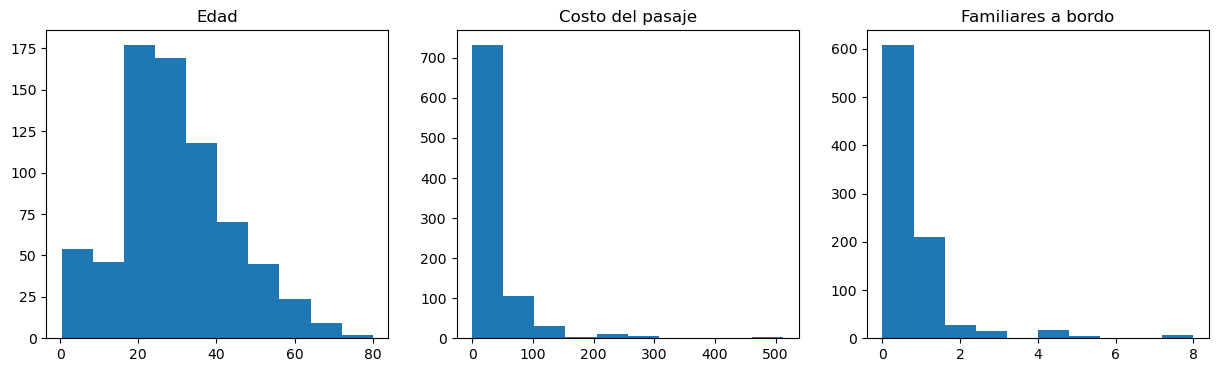

In [1106]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(titanic_df['age'])   # edad
ax[0].set_title('Edad')
ax[1].hist(titanic_df['fare'])  # costo del pasaje
ax[1].set_title('Costo del pasaje')
ax[2].hist(titanic_df['sibsp']) # familiares
ax[2].set_title('Familiares a bordo')

plt.show()


#### Variantes del histograma de edad

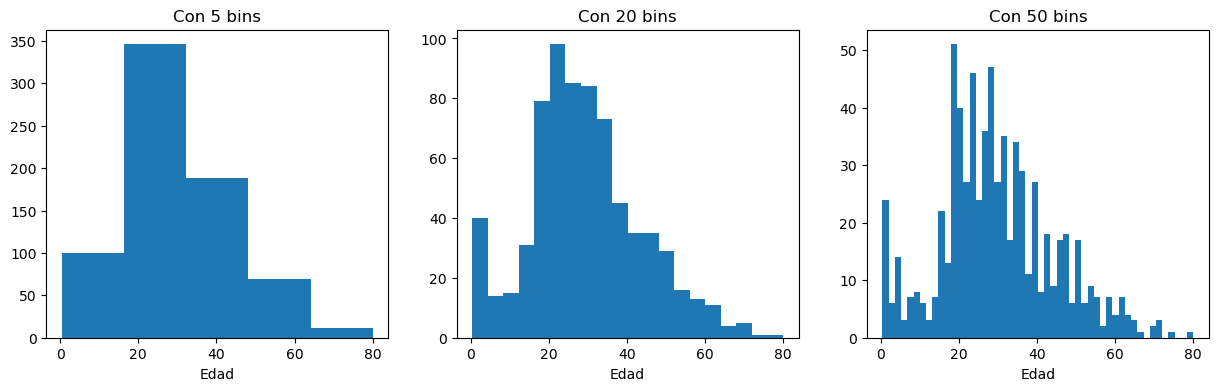

In [1107]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(titanic_df['age'], bins=5)
ax[0].set_title('Con 5 bins')
ax[0].set_xlabel('Edad')
ax[1].hist(titanic_df['age'], bins=20)
ax[1].set_title('Con 20 bins')
ax[1].set_xlabel('Edad')
ax[2].hist(titanic_df['age'], bins=50)
ax[2].set_title('Con 50 bins')
ax[2].set_xlabel('Edad')

plt.show()

#### 1.3. Medidas de tendencia central + histograma

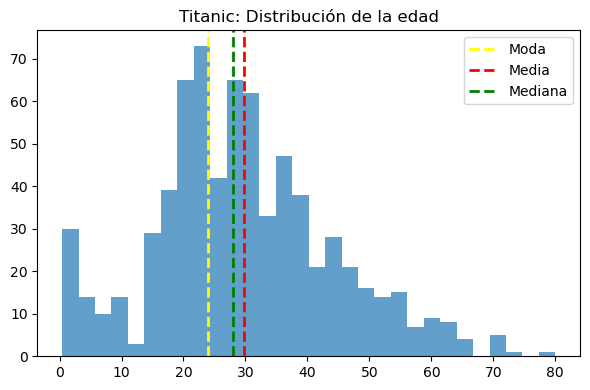

In [1108]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(titanic_df['age'], bins=30, alpha=0.7) # dibujar histograma
ax.axvline(titanic_df['age'].mode()[0], color='yellow', ls='--', lw=2, label='Moda')
ax.axvline(titanic_df['age'].mean(), color='red', ls='--', lw=2, label='Media')
ax.axvline(titanic_df['age'].median(), color='green', ls='--', lw=2, label='Mediana')
ax.set_title('Titanic: Distribución de la edad')
ax.legend()

plt.tight_layout()
plt.show()

#### Comparamos la distribución de las tres variables: edad, costo del pasaje y número de familiares

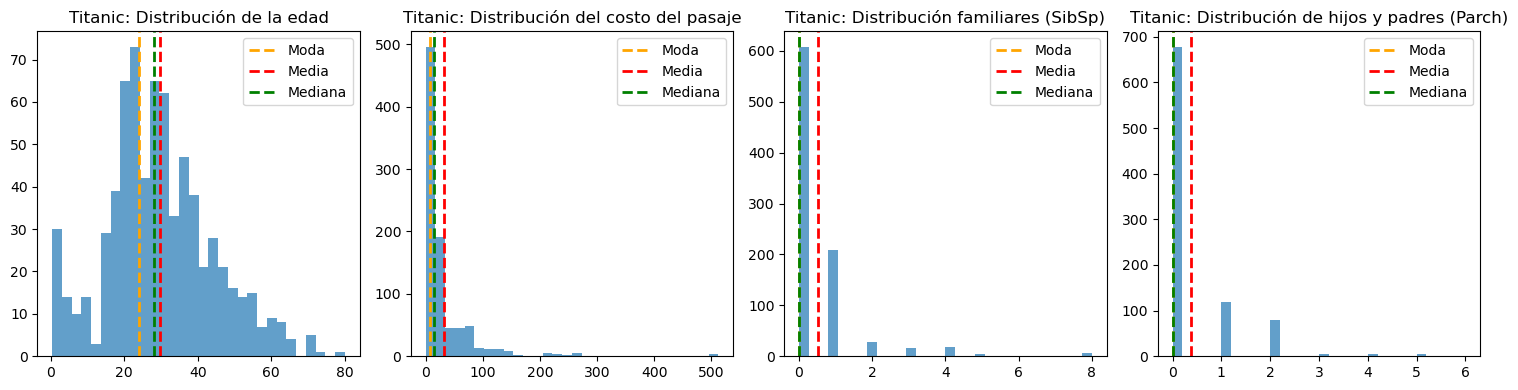

In [1109]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# Función para graficar
def plot_distribution(ax, data, title):
    ax.hist(data, bins=30, alpha=0.7) # dibujar histograma
    ax.axvline(data.mode()[0], color='orange', linestyle='dashed', linewidth=2, label='Moda') # dibujar la moda
    ax.axvline(data.mean(), color='red', linestyle='dashed', linewidth=2, label='Media') # dibujar la media
    ax.axvline(data.median(), color='green', linestyle='dashed', linewidth=2, label='Mediana') # dibujar la mediana
    ax.set_title(title)
    ax.legend()

plot_distribution(axes[0], titanic_df['age'], 'Titanic: Distribución de la edad')
plot_distribution(axes[1], titanic_df['fare'], 'Titanic: Distribución del costo del pasaje')
plot_distribution(axes[2], titanic_df['sibsp'], 'Titanic: Distribución familiares (SibSp)')
plot_distribution(axes[3], titanic_df['parch'], 'Titanic: Distribución de hijos y padres (Parch)')

plt.tight_layout()
plt.show()

#### ¿Qué métrica representa mejor cada variable (edad, costo, familiares)?

#### KDE: Kernel Density Estimation --> estimar la función de densidad de probabilidad (PDF)

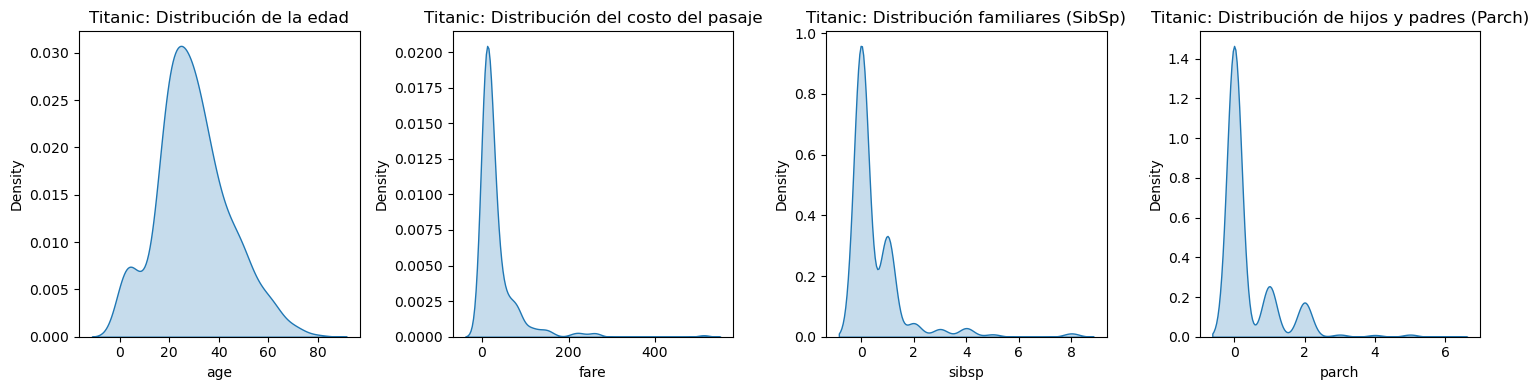

In [1110]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

sns.kdeplot(data=titanic_df, x='age', fill=True, ax=axes[0])
sns.kdeplot(data=titanic_df, x='fare', fill=True, ax=axes[1])
sns.kdeplot(data=titanic_df, x='sibsp', fill=True, ax=axes[2])
sns.kdeplot(data=titanic_df, x='parch', fill=True, ax=axes[3])
axes[0].set_title('Titanic: Distribución de la edad')
axes[1].set_title('Titanic: Distribución del costo del pasaje')
axes[2].set_title('Titanic: Distribución familiares (SibSp)')
axes[3].set_title('Titanic: Distribución de hijos y padres (Parch)')

plt.tight_layout()
plt.show()

### 1.4. Medidas de dispersión: varianza y desviación estándar
<hr style="border:1px solid gray">


In [1111]:
# Calculamos la media, varianza y desviación estándar del largo de las aletas
age_media = titanic_df['age'].mean()
age_var = titanic_df['age'].var()
age_std_dev = titanic_df['age'].std()
print(f'La media de la edad de los pasajeros es {age_media:.2f} años, \nla varianza es {age_var:.4f} y \nla desviación estándar es {age_std_dev:.4f} años')

La media de la edad de los pasajeros es 29.70 años, 
la varianza es 211.0191 y 
la desviación estándar es 14.5265 años


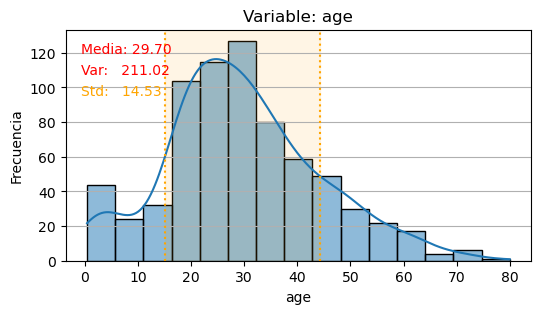

In [1112]:
# Usamos la función que definimos para graficar (ver sección HELPER FUNCTIONS)
plot_histograma(titanic_df, 'age')

### 1.5. Cuantiles y rango intercuartil
<hr style="border:1px solid gray">


In [1113]:
age_Q1, age_Q2, age_Q3 = cuartiles(titanic_df['age'])

print("Q1 (25%):", age_Q1)
print("Q2 (Mediana, 50%):", age_Q2)
print("Q3 (75%):", age_Q3)

Q1 (25%): 20.125
Q2 (Mediana, 50%): 28.0
Q3 (75%): 38.0


In [1114]:
age_IQR = age_Q3 - age_Q1
print("Rango intercuartil (IQR):", age_IQR)

Rango intercuartil (IQR): 17.875


#### Visualizamos con Boxplots

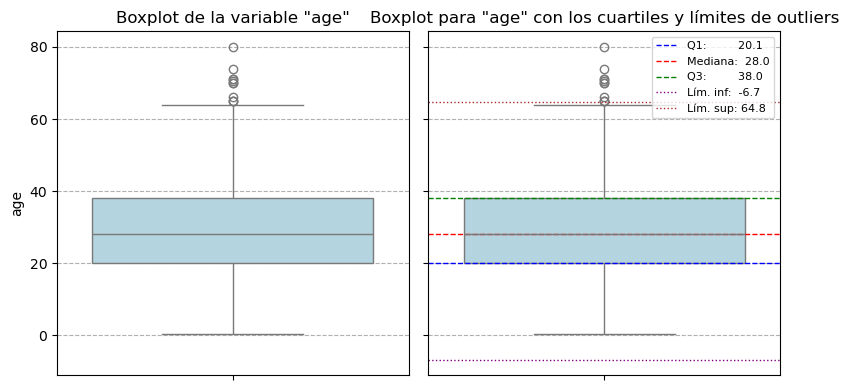

In [1115]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

age = titanic_df['age'].dropna()

# Límites teóricos para detectar outliers
lower_limit = age_Q1 - 1.5 * age_IQR
upper_limit = age_Q3 + 1.5 * age_IQR

# ax[0]: Boxplot como viene
sns.boxplot(data=titanic_df, y='age', color="lightblue", ax=ax[0])
#sns.boxplot(data=titanic_df, y='age', color="lightblue", showfliers=False, ax=ax[0]) # En caso que no queramos mostrar los outliers en el boxplot
ax[0].set_title('Boxplot de la variable "age"')
ax[0].grid(axis='y', ls='--')

# ax[1]: Boxplot con detalles
sns.boxplot(data=titanic_df, y='age', color="lightblue", ax=ax[1])
ax[1].axhline(age_Q1,      color='blue',   linestyle='--', linewidth=1, label=f'Q1:         {age_Q1:.1f}')
ax[1].axhline(age_Q2,      color='red',    linestyle='--', linewidth=1, label=f'Mediana:  {age_Q2:.1f}')
ax[1].axhline(age_Q3,      color='green',  linestyle='--', linewidth=1, label=f'Q3:         {age_Q3:.1f}')
ax[1].axhline(lower_limit, color='purple', linestyle=':',  linewidth=1, label=f'Lím. inf:  {lower_limit:.1f}')
ax[1].axhline(upper_limit, color='brown',  linestyle=':',  linewidth=1, label=f'Lím. sup: {upper_limit:.1f}')
ax[1].set_title('Boxplot para "age" con los cuartiles y límites de outliers')
ax[1].legend(fontsize=8)
ax[1].grid(axis='y', ls='--')

plt.tight_layout()
plt.show()

### 1.6. Medidas de forma: skewness (asimetría) y curtosis
<hr style="border:1px solid gray">


In [1116]:
# Con Pandas
print(f"Asímetría de la variable 'age': {titanic_df['age'].skew()}")
print(f"Curtosis de la variable 'age': {titanic_df['age'].kurtosis()}")

Asímetría de la variable 'age': 0.38910778230082704
Curtosis de la variable 'age': 0.17827415364210353


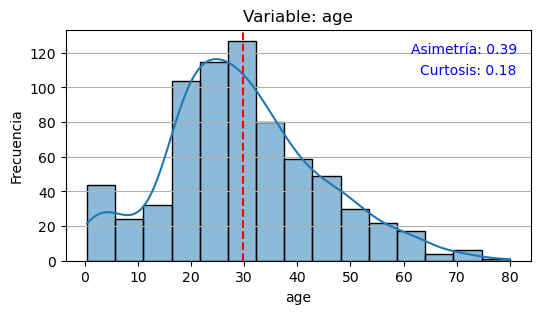

In [1117]:
plot_histograma(titanic_df, 'age', mvd= False, snk=True)

### 1.7. Estadística descriptiva completa 
<hr style="border:1px solid gray">


In [1118]:
print("Estadística descriptiva del dataset Titanic:\n")
titanic_df.describe()

Estadística descriptiva del dataset Titanic:



,age,sibsp,parch,fare
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208
std,14.526497,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,0.000000,0.000000,7.910400
50%,28.000000,0.000000,0.000000,14.454200
75%,38.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


In [1119]:
# estadística básica + percentiles
titanic_df.describe(percentiles=[.1,.9,.95])

,age,sibsp,parch,fare
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208
std,14.526497,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
10%,14.000000,0.000000,0.000000,7.550000
50%,28.000000,0.000000,0.000000,14.454200
90%,50.000000,1.000000,2.000000,77.958300
95%,56.000000,3.000000,2.000000,112.079150
max,80.000000,8.000000,6.000000,512.329200


#### Con Scipy (incluye skewness y kurtosis)

In [1120]:
# Scipy scipy.stats.describe devuelve un objeto con estadísticas descriptivas
ed_titanic = st.describe(titanic_df[['age', 'fare', 'sibsp', 'parch']].dropna())

ed_titanic_df = pd.DataFrame({  
    'Observaciones': ed_titanic.nobs,
    'Min': ed_titanic.minmax[0],
    'Max': ed_titanic.minmax[1],
    'Media': ed_titanic.mean,
    'Varianza': ed_titanic.variance,
    'Asimetría': ed_titanic.skewness,
    'Curtosis': ed_titanic.kurtosis}, index=titanic_df[['age', 'fare', 'sibsp', 'parch']].columns)

ed_titanic_df.head()


,Observaciones,Min,Max,Media,Varianza,Asimetría,Curtosis
age,714,0.42,80.0000,29.699118,211.019125,0.388290,0.168637
fare,714,0.00,512.3292,34.694514,2800.413100,4.643848,30.699725
sibsp,714,0.00,5.0000,0.512605,0.864497,2.514280,6.987321
parch,714,0.00,6.0000,0.431373,0.728103,2.613409,8.782859


---
### 2. Exploración de VARIABLES CATEGÓRICAS



#### 2.1. Vemos frecuencias y categorías

In [1121]:
# Variable 'who'
print_categorias(titanic_df, 'who')

Cantidad de categorías que tiene la variable 'who': 3

Nombres de categorías presentes en la variable 'who': ['man', 'woman', 'child']
Categories (3, object): ['child', 'man', 'woman']

Frecuencia de cada categoría en la variable 'who':
who
man      537
woman    271
child     83
Name: count, dtype: int64



In [1122]:
# Variable 'embarked_town'
print_categorias(titanic_df, 'embark_town')

Cantidad de categorías que tiene la variable 'embark_town': 3

Nombres de categorías presentes en la variable 'embark_town': ['Southampton', 'Cherbourg', 'Queenstown', NaN]
Categories (3, object): ['Cherbourg', 'Queenstown', 'Southampton']

Frecuencia de cada categoría en la variable 'embark_town':
embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64



In [1123]:
# Variable 'class'
print_categorias(titanic_df, 'class')

Cantidad de categorías que tiene la variable 'class': 3

Nombres de categorías presentes en la variable 'class': ['Third', 'First', 'Second']
Categories (3, object): ['First' < 'Second' < 'Third']

Frecuencia de cada categoría en la variable 'class':
class
Third     491
First     216
Second    184
Name: count, dtype: int64



#### 2.2. Descripción de categóricas con la función $\texttt{describe}$

In [1124]:
titanic_df.describe(include='category')

# count = cant. de datos no nulos
# unique = cantidad de categorias distintas
# top = categoria con mayor frecuencia
# freq = frecuencia de la categoria top
# CUIDADO! en el caso multimodal, pandas elige y muestra una categoría arbitrariamente 

,survived,pclass,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891,891,891,889,891,891,891,203,889,891,891
unique,2,3,2,3,3,3,2,7,3,2,2
top,0,3,male,S,Third,man,True,C,Southampton,no,True
freq,549,491,577,644,491,537,537,59,644,549,537


#### 2.3. Visualizaciones para categóricas

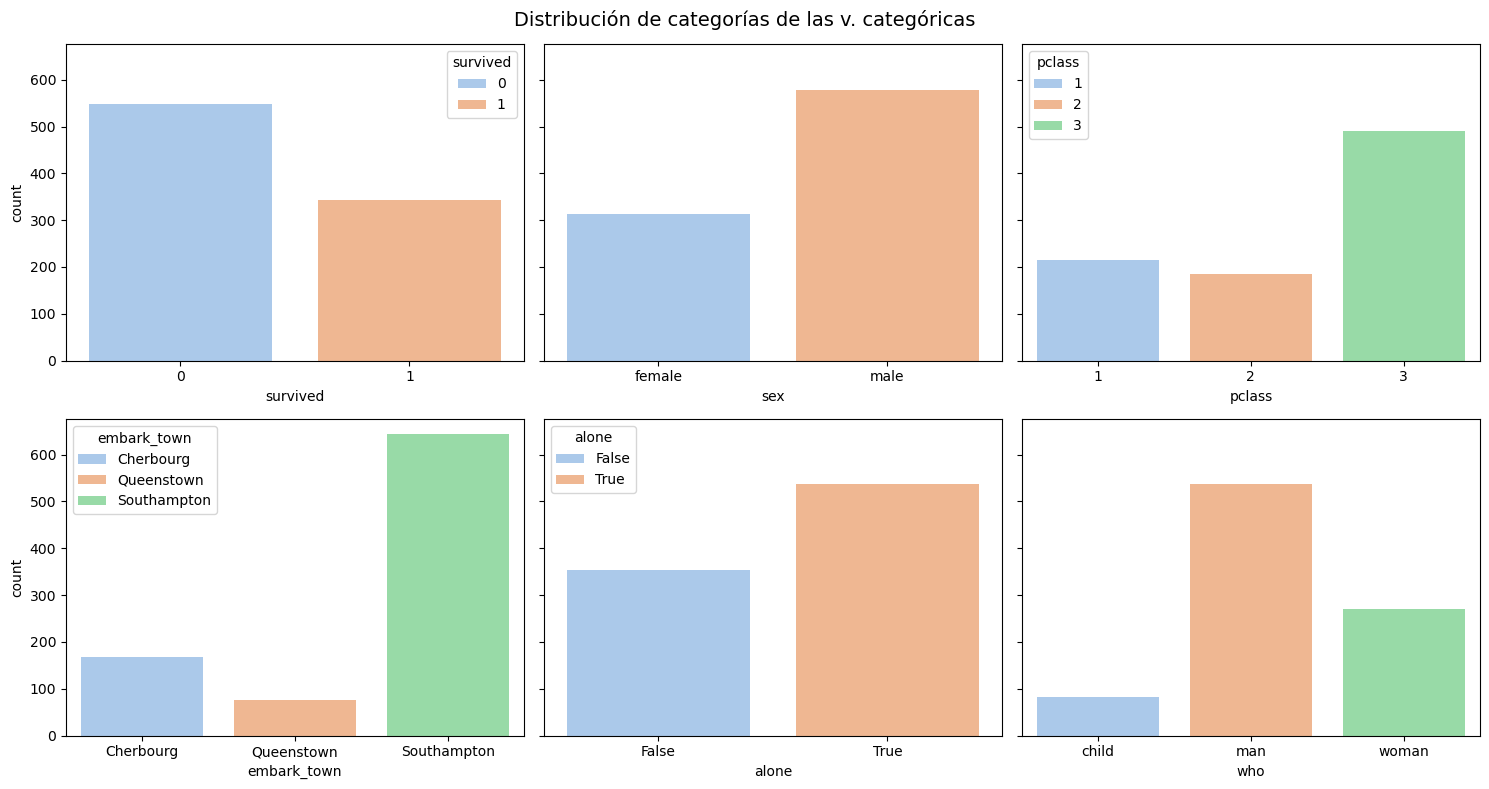

In [1125]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
axes = axes.flatten()  

for i, col in enumerate(['survived', 'sex', 'pclass', 'embark_town', 'alone', 'who']):
    sns.countplot(x=col, data=titanic_df, hue=col, palette='pastel', ax=axes[i])

plt.suptitle('Distribución de categorías de las v. categóricas', fontsize=14)
plt.tight_layout()
plt.show()

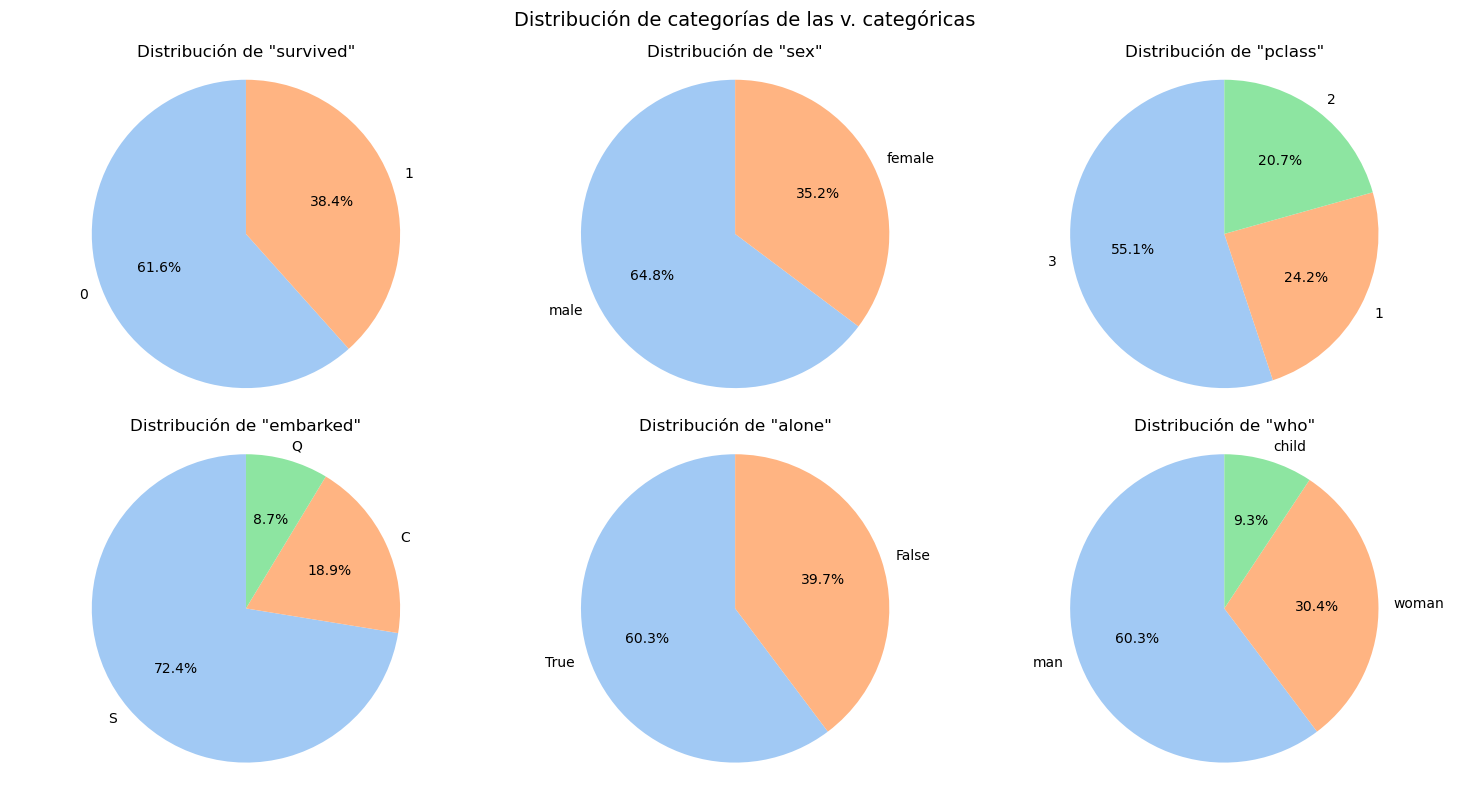

In [1126]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten() 

for i, col in enumerate(['survived', 'sex', 'pclass', 'embarked', 'alone', 'who']):
    plot_pie(titanic_df, col, ax=axes[i])


plt.suptitle('Distribución de categorías de las v. categóricas', fontsize=14)
plt.tight_layout()
plt.show()

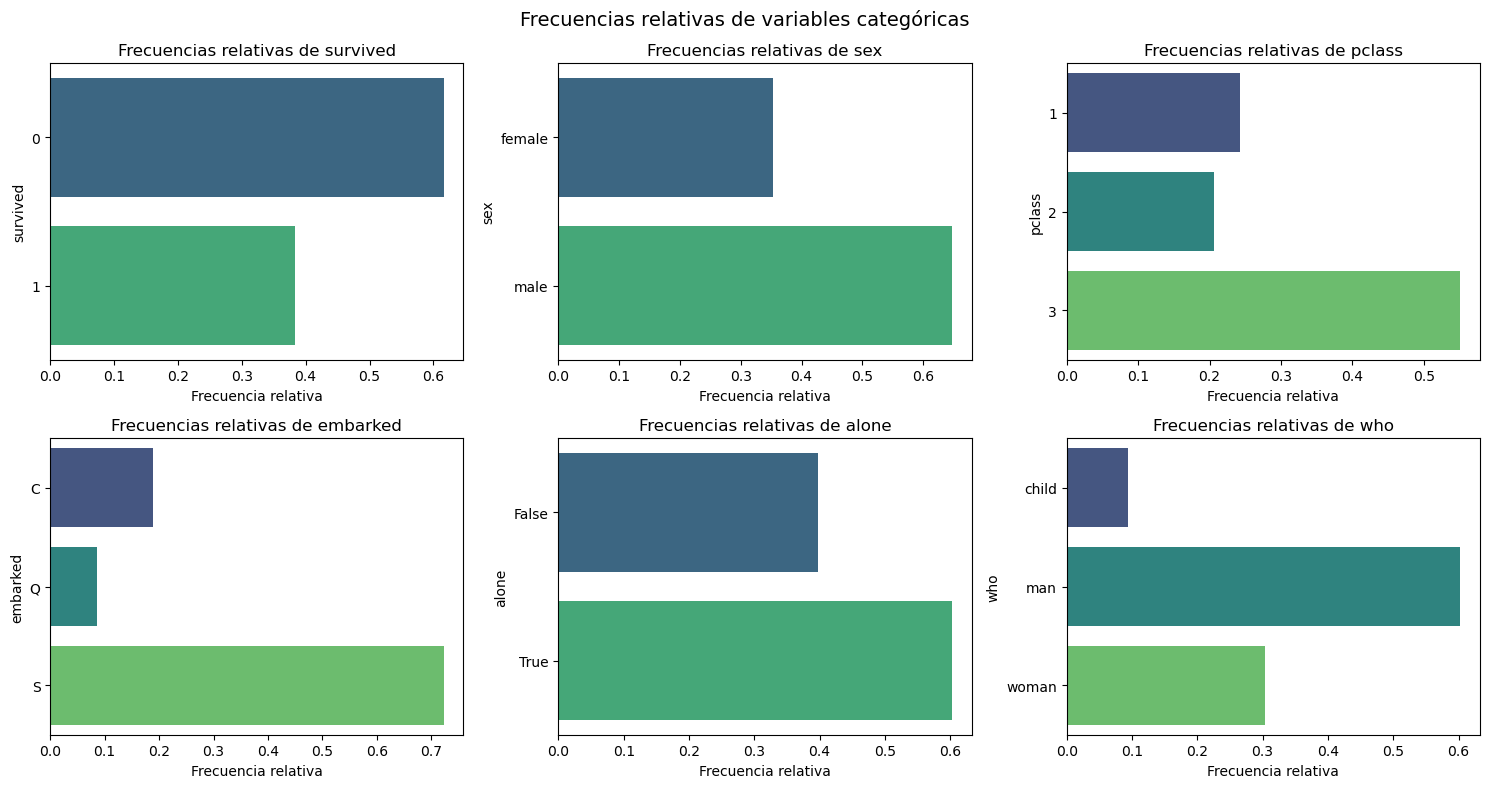

In [1127]:

# Plots de frecuencias relativas
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(['survived', 'sex', 'pclass', 'embarked', 'alone', 'who']):
    plot_frecuencias_relativas(titanic_df, col, ax=axes[i])

plt.suptitle('Frecuencias relativas de variables categóricas', fontsize=14)
plt.tight_layout()
plt.show()

---
### 3. Relaciones entre variables

#### 3.1. Numérica-numérica

<Axes: xlabel='age', ylabel='fare'>

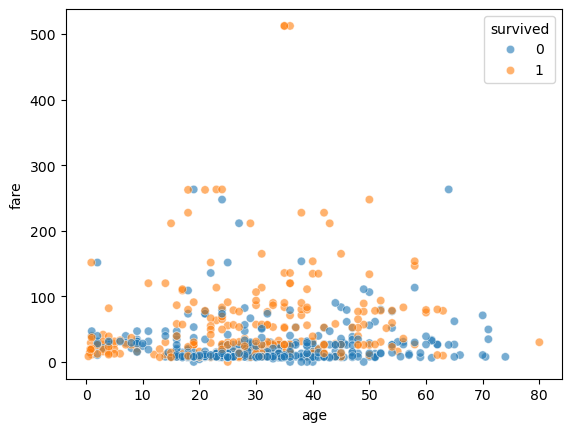

In [1128]:
sns.scatterplot(data=titanic_df, x='age', y='fare', hue='survived', alpha=0.6)

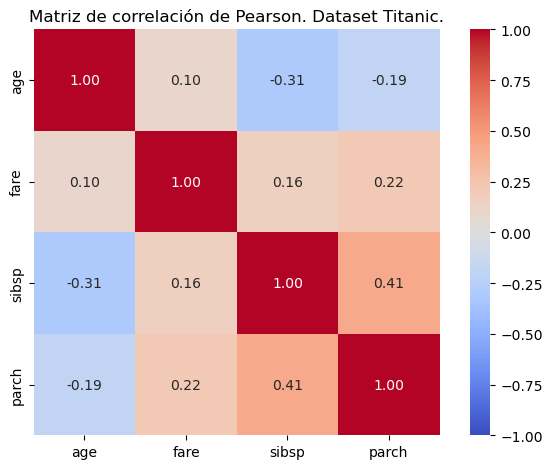

In [1129]:
# Opción 1: mostrar toda la matriz de correlación como sale
corr_matrix = titanic_df[titanic_numericas].corr()

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True)
plt.title('Matriz de correlación de Pearson. Dataset Titanic.')
plt.tight_layout()
plt.show()

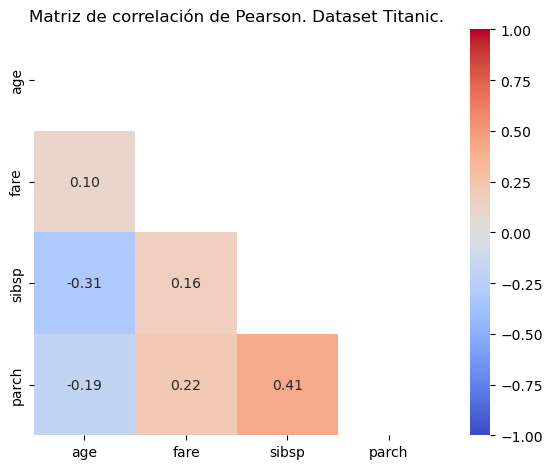

In [1130]:
# Opción 2: si no queremos ver información redundante

# Creamos una máscara para ocultar la mitad superior de la matriz
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool)) 

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, mask=mascara) # Se filtra aplicando una máscara
plt.title('Matriz de correlación de Pearson. Dataset Titanic.')
plt.tight_layout()
plt.show()

#### 3.2. Categórica-categórica

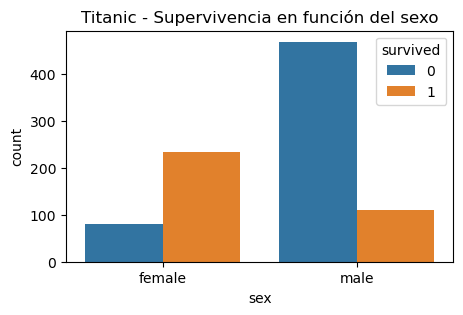

In [1131]:
# Cuántas personas sobrevivieron de cada sexo?
plt.figure(figsize=(5, 3))
sns.countplot(x='sex', hue='survived', data=titanic_df)
plt.title("Titanic - Supervivencia en función del sexo")
plt.show()

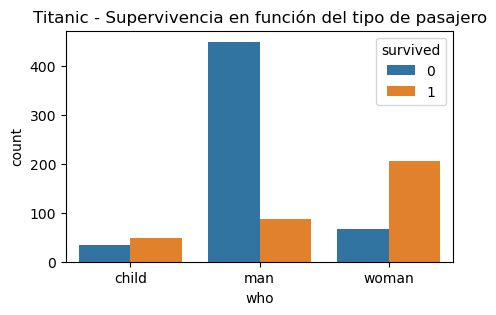

In [1132]:
# Cuántas personas sobrevivieron de tipo de pasajero?
plt.figure(figsize=(5, 3))
sns.countplot(x='who', hue='survived', data=titanic_df)
plt.title("Titanic - Supervivencia en función del tipo de pasajero")
plt.show()

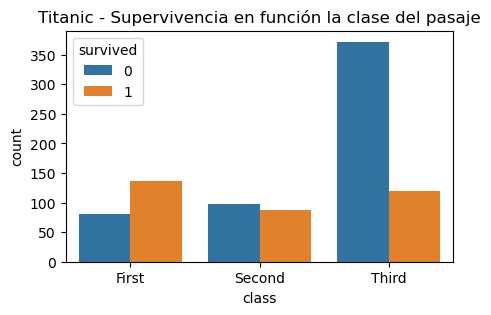

In [1133]:
# Cómo se relaciona la supervivencia con la clase del pasaje?
plt.figure(figsize=(5, 3))
sns.countplot(x='class', hue='survived', data=titanic_df)
plt.title("Titanic - Supervivencia en función la clase del pasaje")
plt.show()

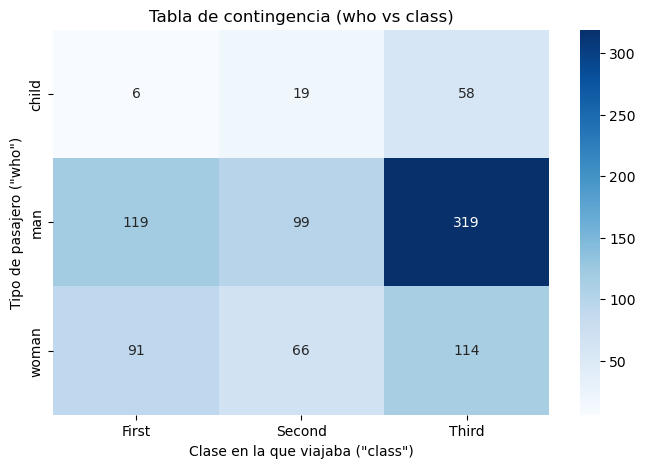

In [1134]:
plt.figure(figsize=(8, 5))
cross_tab = pd.crosstab(titanic_df['who'], titanic_df['class'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Tabla de contingencia (who vs class)')
plt.xlabel('Clase en la que viajaba ("class")')
plt.ylabel('Tipo de pasajero ("who")')
plt.show()

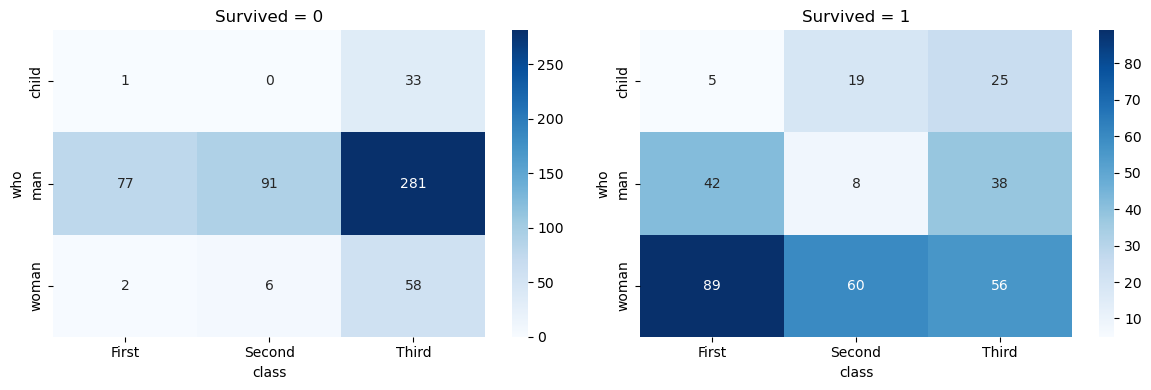

In [1135]:
cross_tab = pd.crosstab(titanic_df['who'], [titanic_df['survived'], titanic_df['class']])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, surv in enumerate([0, 1]):
    sns.heatmap(cross_tab[surv], annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Survived = {surv}')

plt.tight_layout()
plt.show()

Problema: no sabemos qué porcentaje del total representan estos números.

Otra opción: Tabla de contingencia normalizada

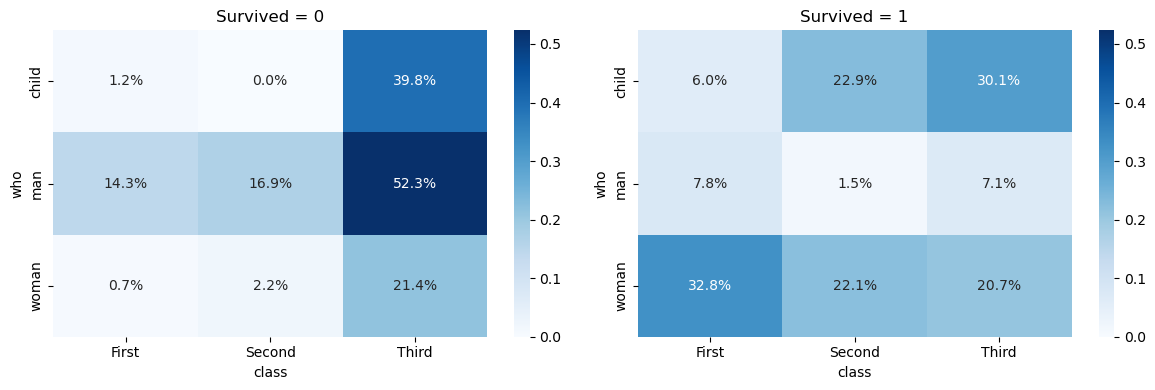

In [1136]:
cross_tab_pct = pd.crosstab(titanic_df['who'], [titanic_df['survived'], titanic_df['class']], 
                             normalize='index')  # normalizar por filas para obtener porcentajes dentro de cada tipo de pasajero

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, surv in enumerate([0, 1]):
    sns.heatmap(cross_tab_pct[surv], annot=True, fmt='.1%', cmap='Blues', ax=axes[i],
                vmin=0, vmax=cross_tab_pct.values.max())  # trabajar sobre la misma escala
    axes[i].set_title(f'Survived = {surv}')

plt.tight_layout()
plt.show()

#### 3.3. Numéricas-categóricas

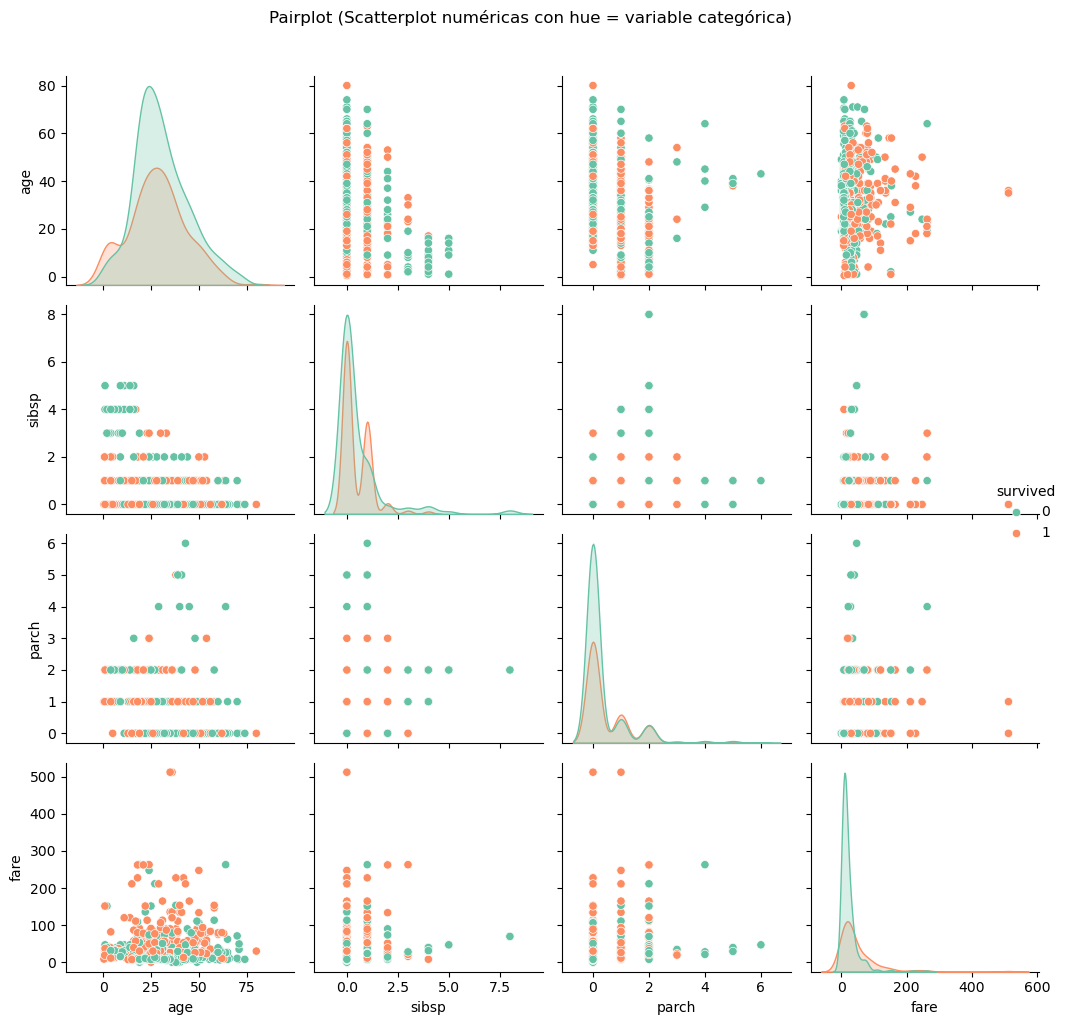

In [1137]:
grafico = sns.pairplot(data=titanic_df, hue='survived', palette='Set2')
grafico.figure.suptitle('Pairplot (Scatterplot numéricas con hue = variable categórica)', y=1.02) # Hago todo esto para que me muestre el título del gráfico, porque con pairplot no funciona plt.title()
plt.tight_layout()
plt.show()

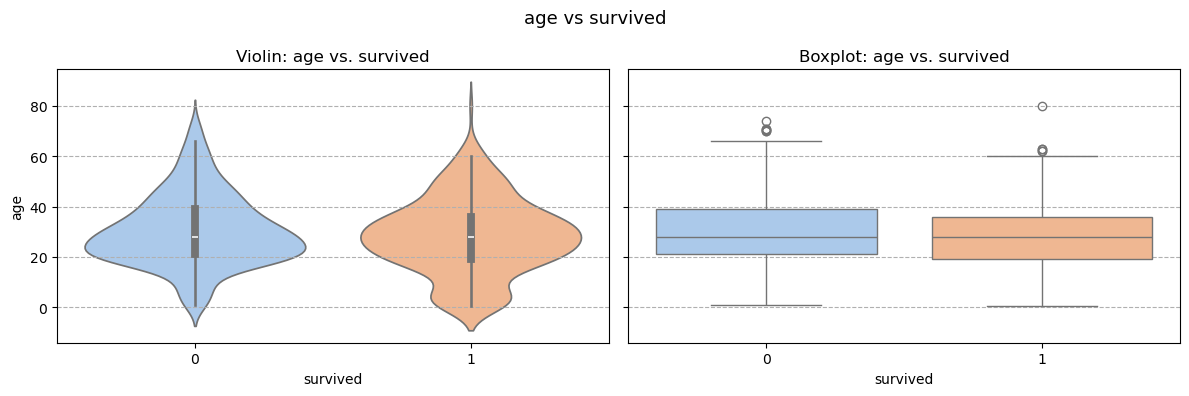

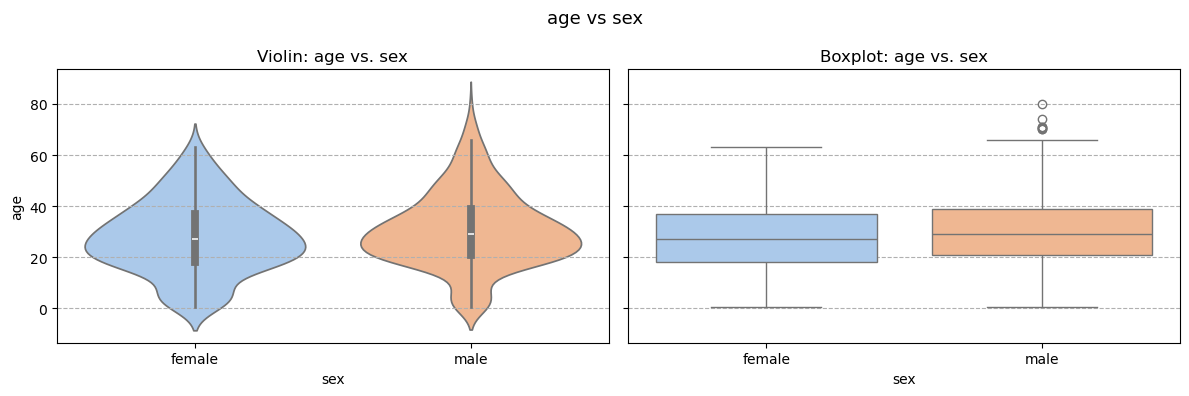

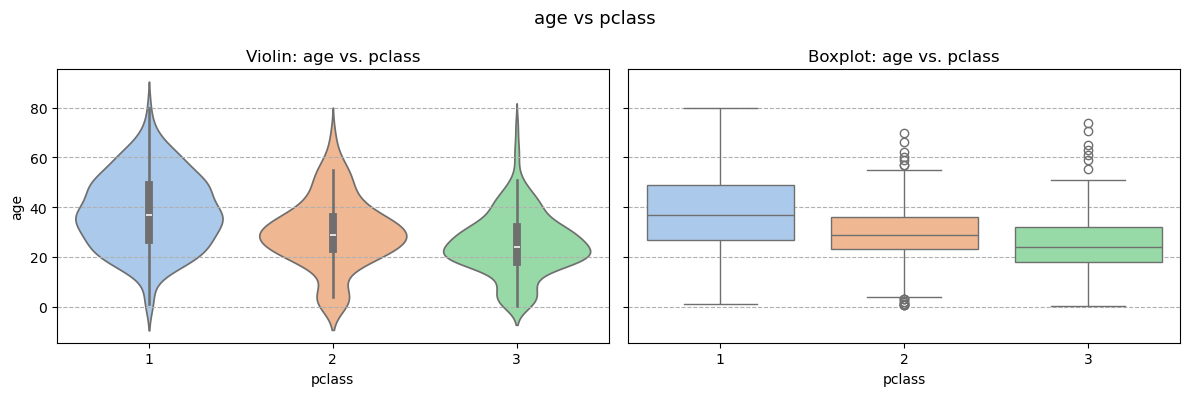

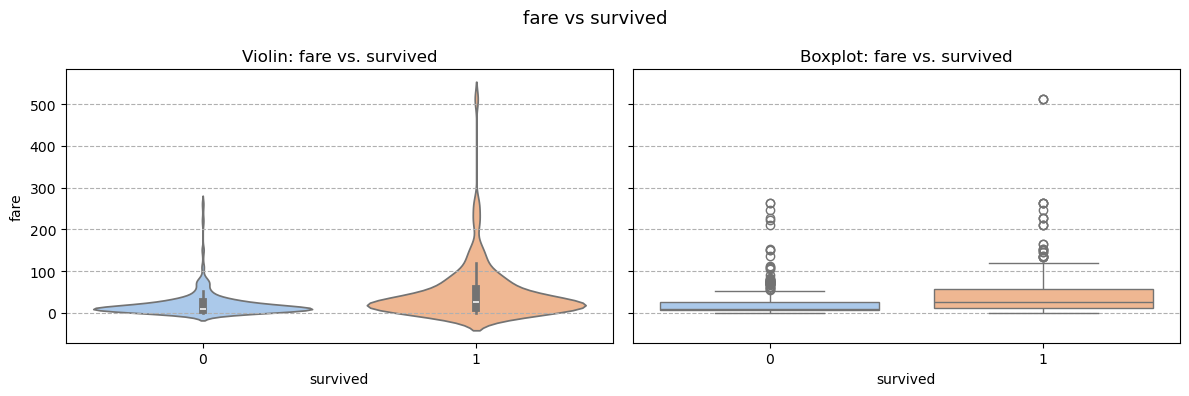

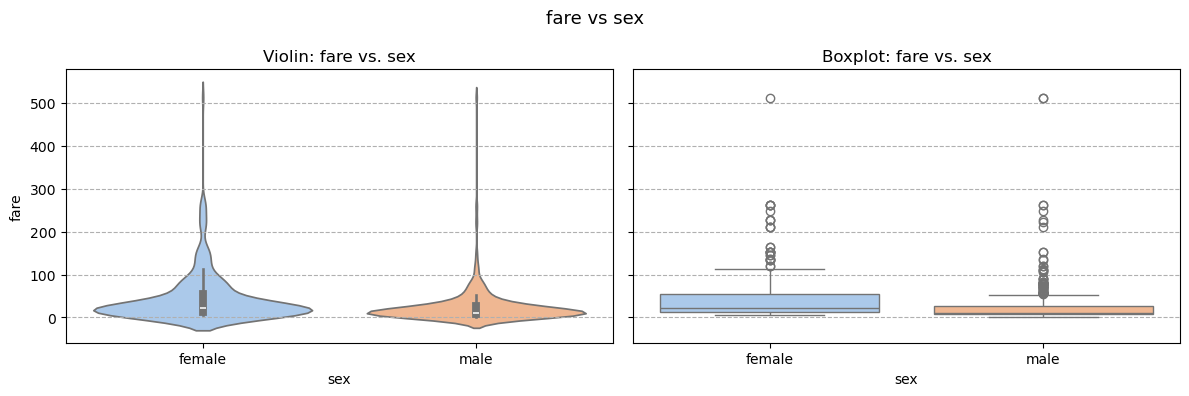

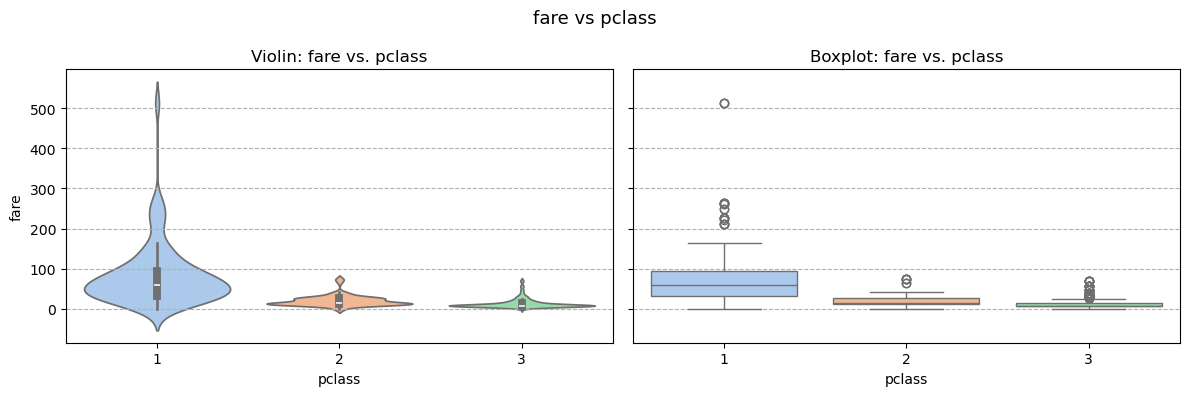

In [1138]:
cat_cols = ['survived', 'sex', 'pclass']

for num in ['age', 'fare']:
    for cat in cat_cols:
        plot_violin_box(titanic_df, num, cat)